  TRAFFIC ACCIDENT DATA ANALYSIS

[STEP 4] Loading dataset...
Dataset loaded successfully.
Rows    : 2,857
Columns : 46

[STEP 5] Data Cleaning
--------------------------------------------------
Removed 0 rows with invalid datetime values.

Missing values summary:
                       Missing   Pct%
End_Lat                   2857  100.0
End_Lng                   2857  100.0
Precipitation(in)         2669   93.4
Wind_Chill(F)             2397   83.9
Wind_Speed(mph)            240    8.4
Visibility(mi)              29    1.0
Weather_Condition           22    0.8
Temperature(F)              16    0.6
Humidity(%)                 16    0.6
Pressure(in)                15    0.5
Wind_Direction              15    0.5
Weather_Timestamp           15    0.5
Distance(mi)                 1    0.0
Start_Lng                    1    0.0
Street                       1    0.0
Description                  1    0.0
County                       1    0.0
City                         1    0.0
Airport_Code 

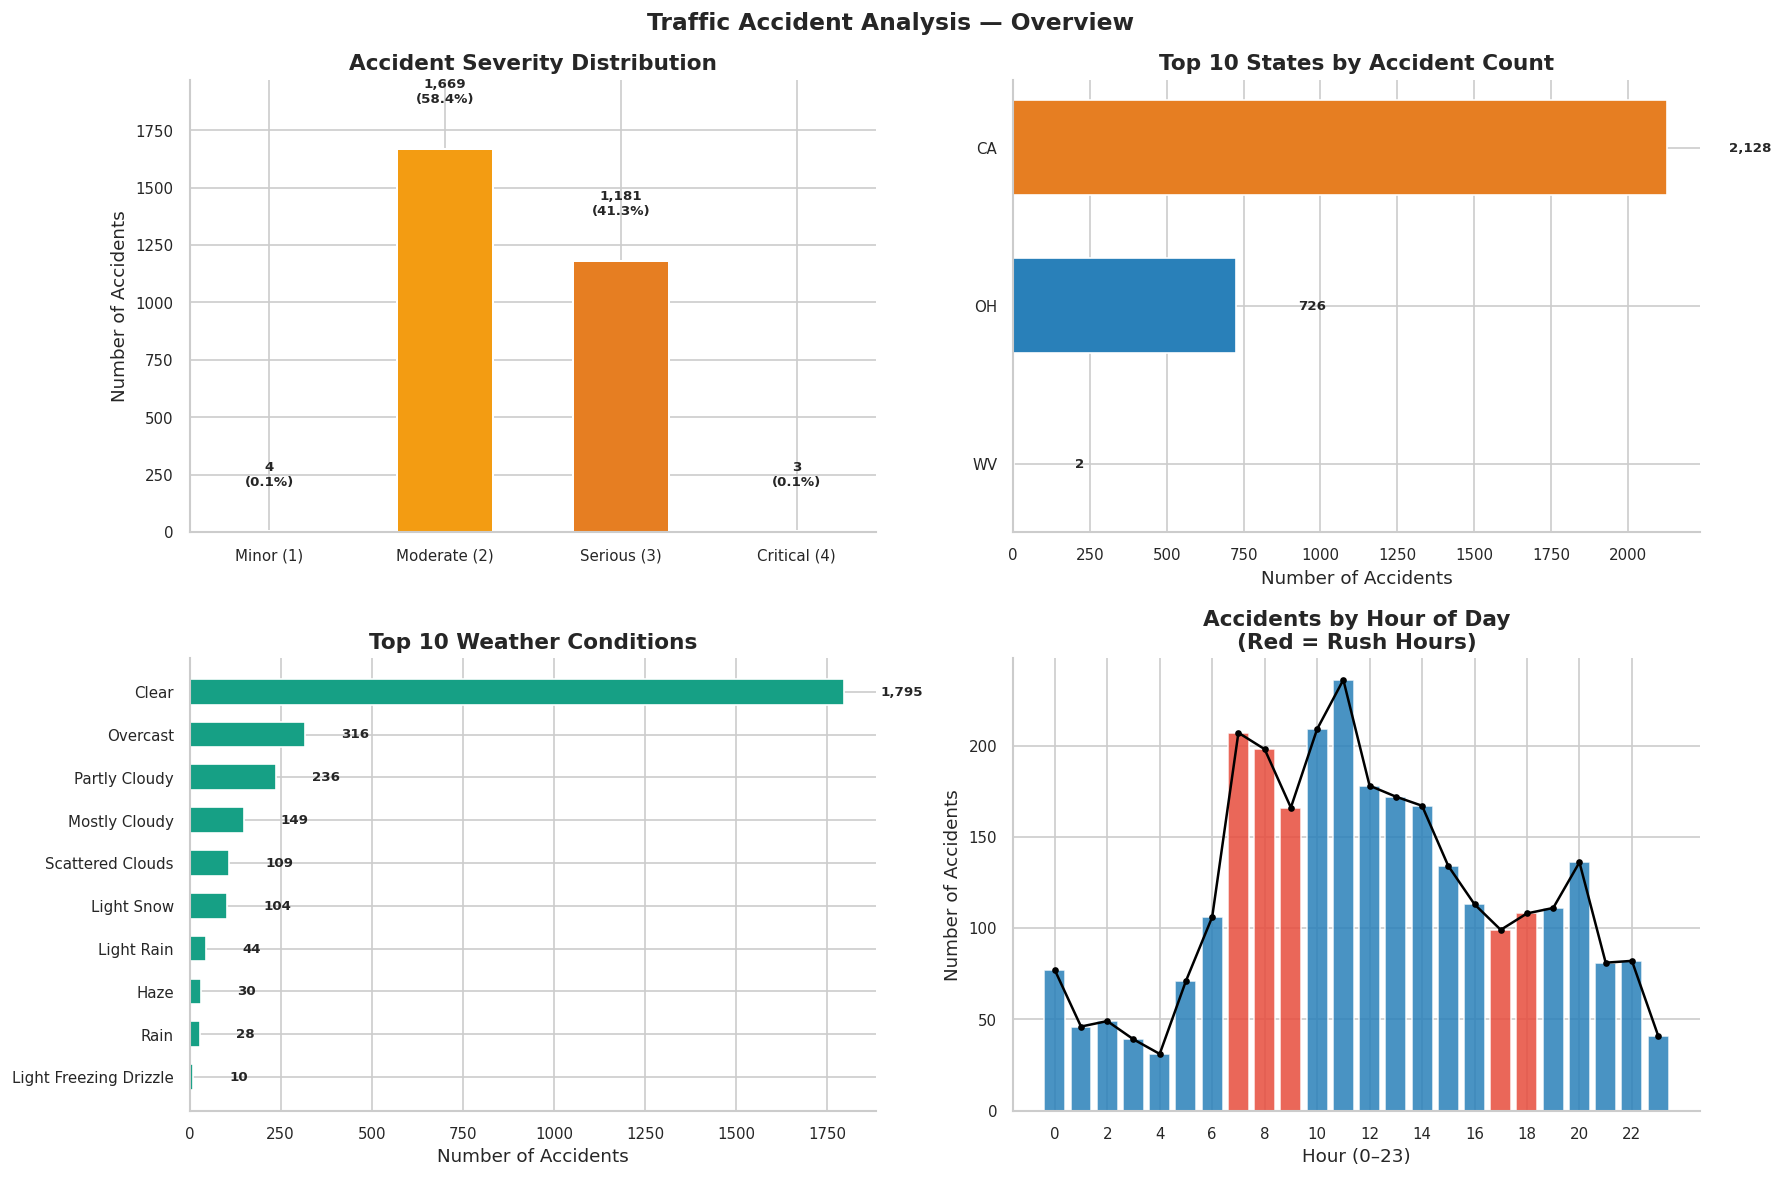


FIGURE 1 — OBSERVATIONS:
CA dominates with 2,128 accidents.
Clear is the most frequent weather condition with 1,795 accidents.
Peak accident hour is around 11:00.

[STEP 9] Creating Figure 2 — Time and Road Features


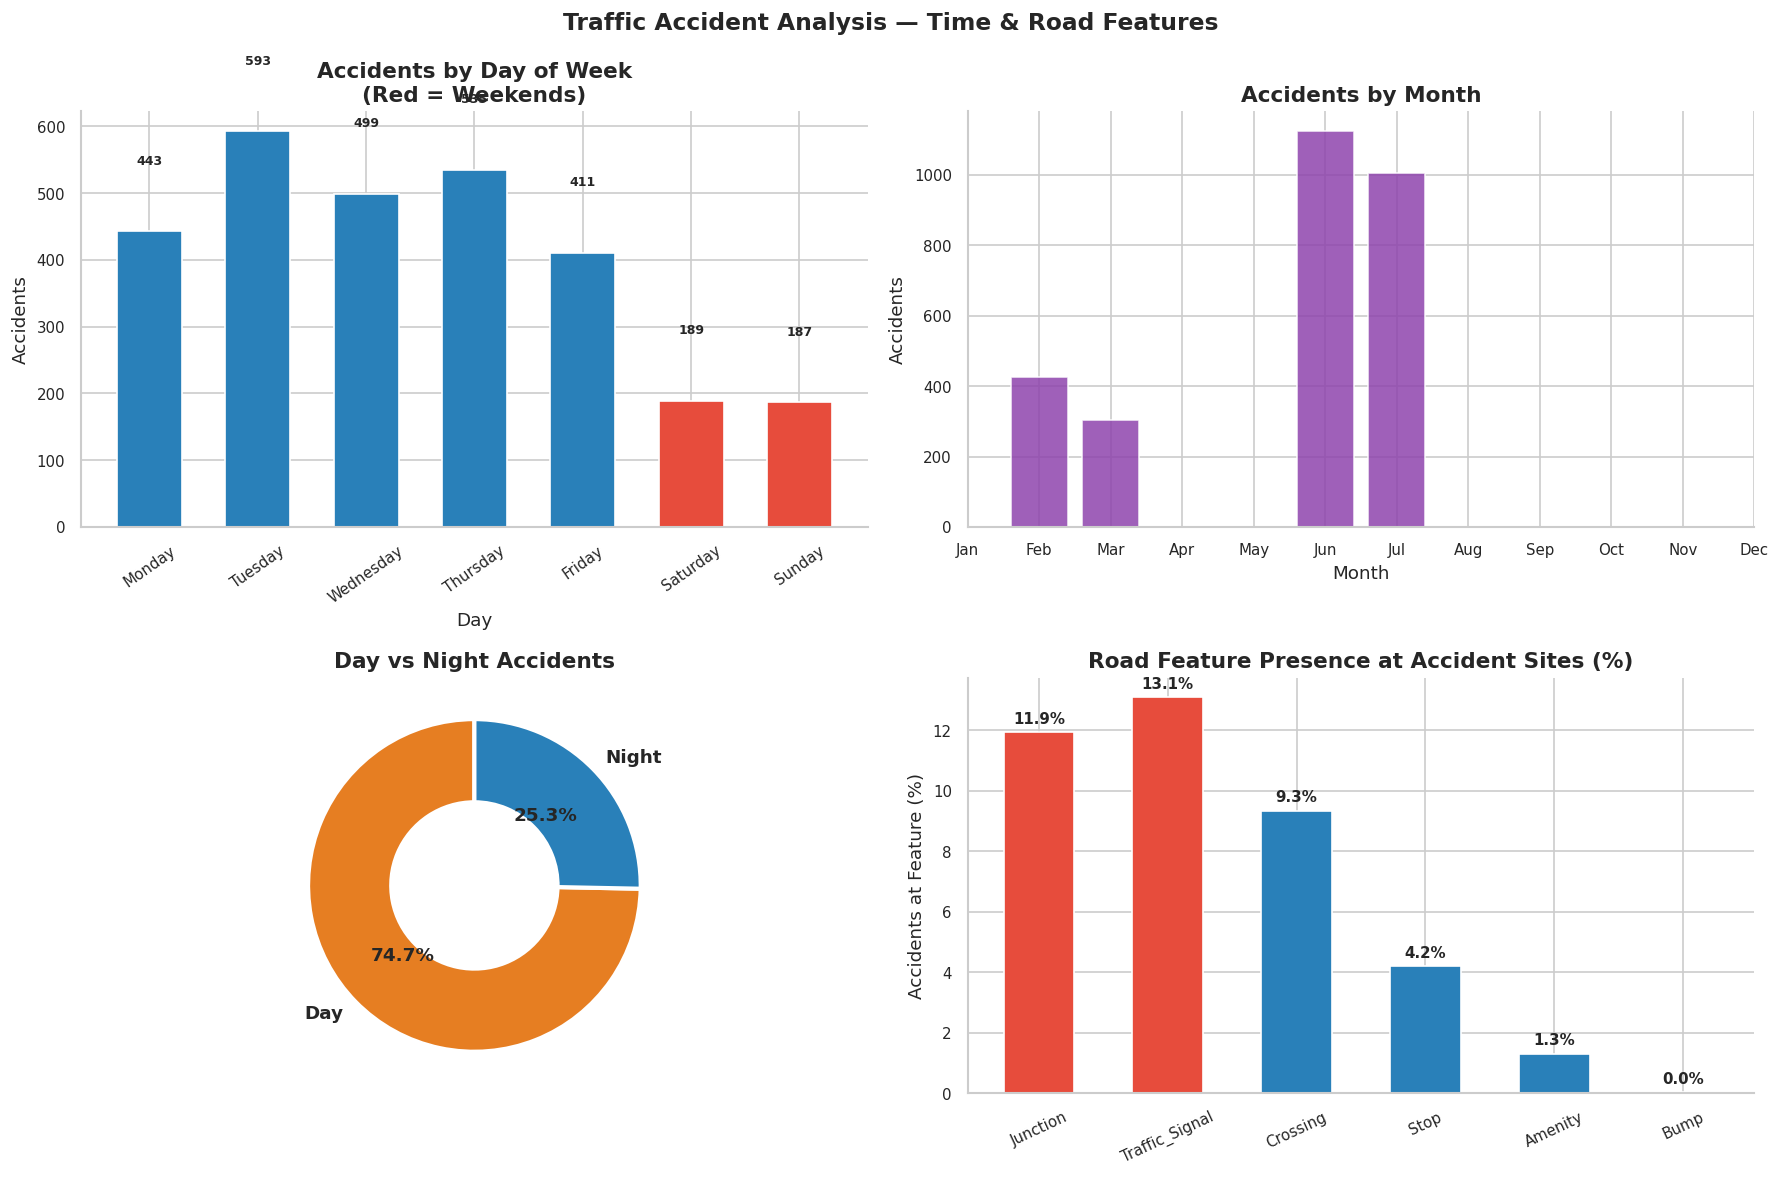


[STEP 10] Creating Figure 3 — Deep Dive


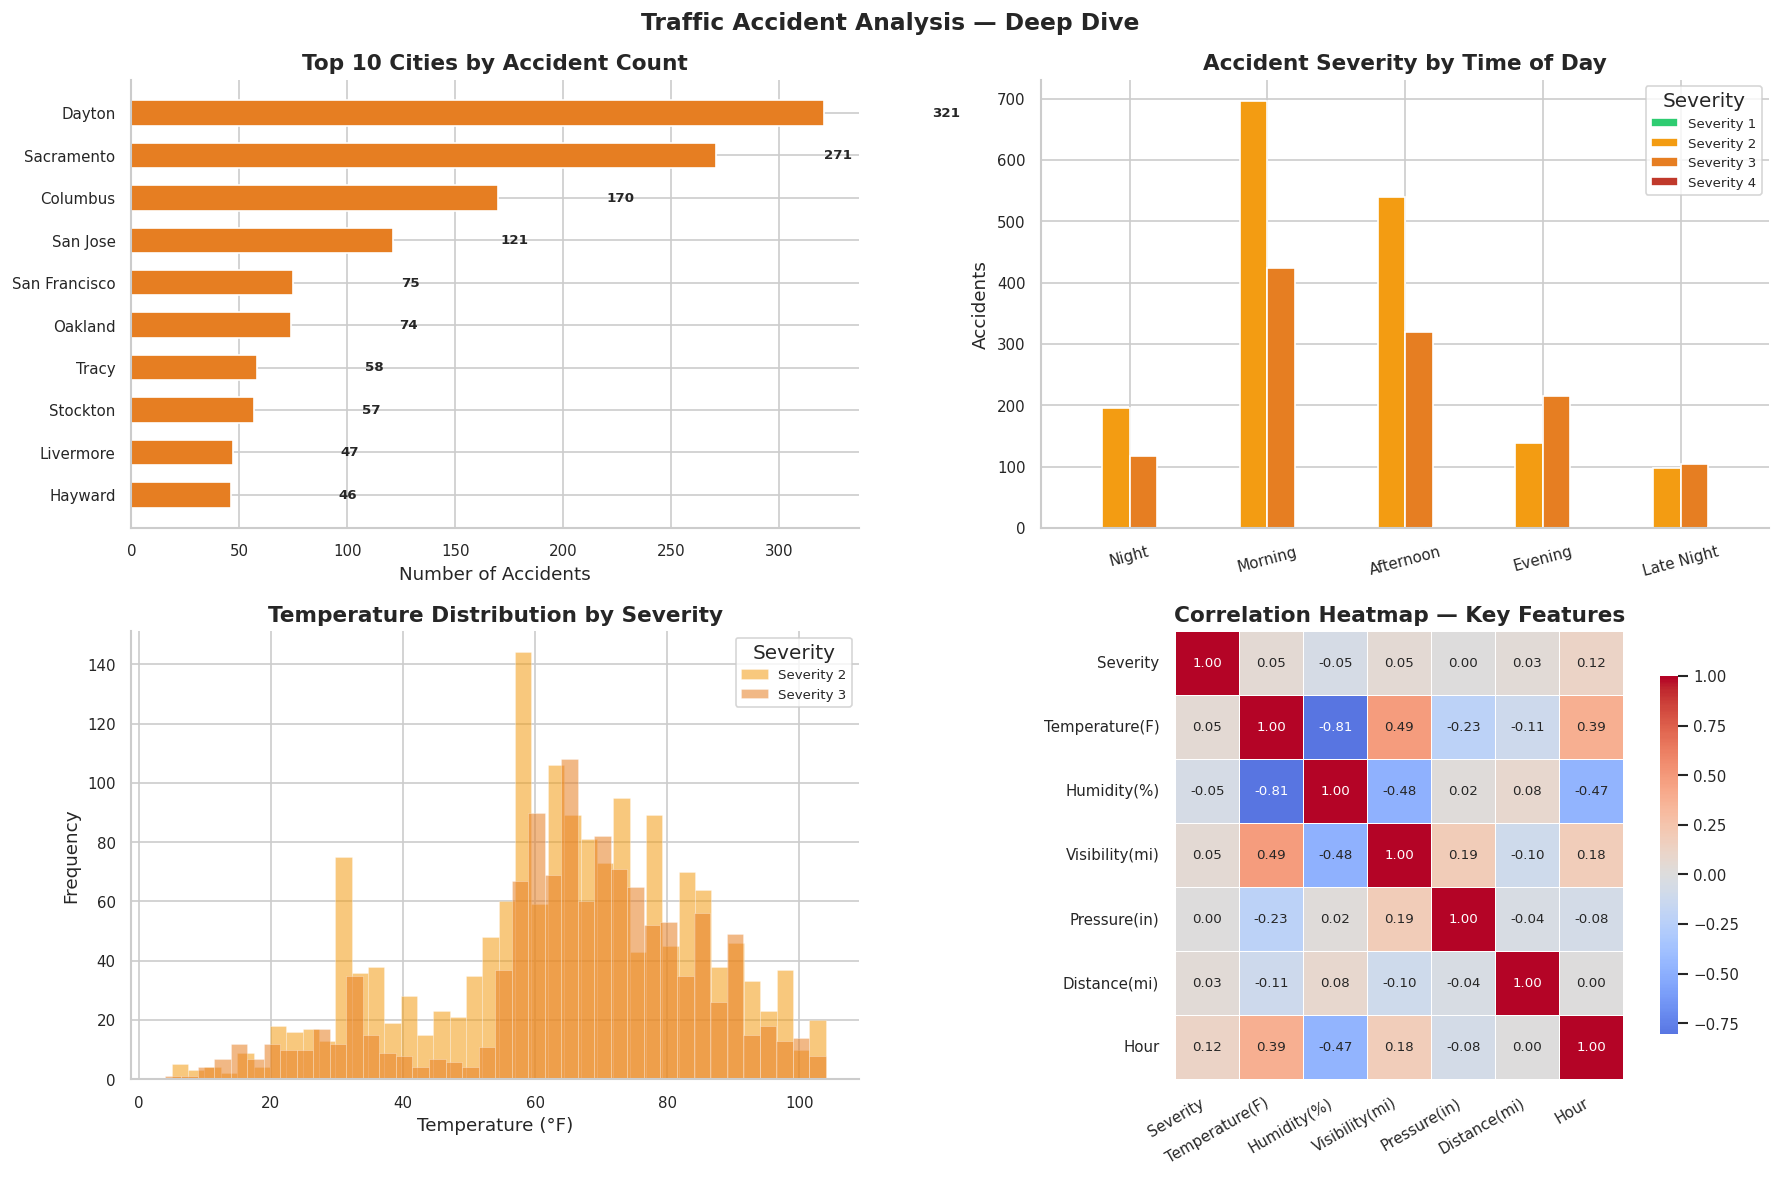


[STEP 11] Creating Weather vs Severity Chart


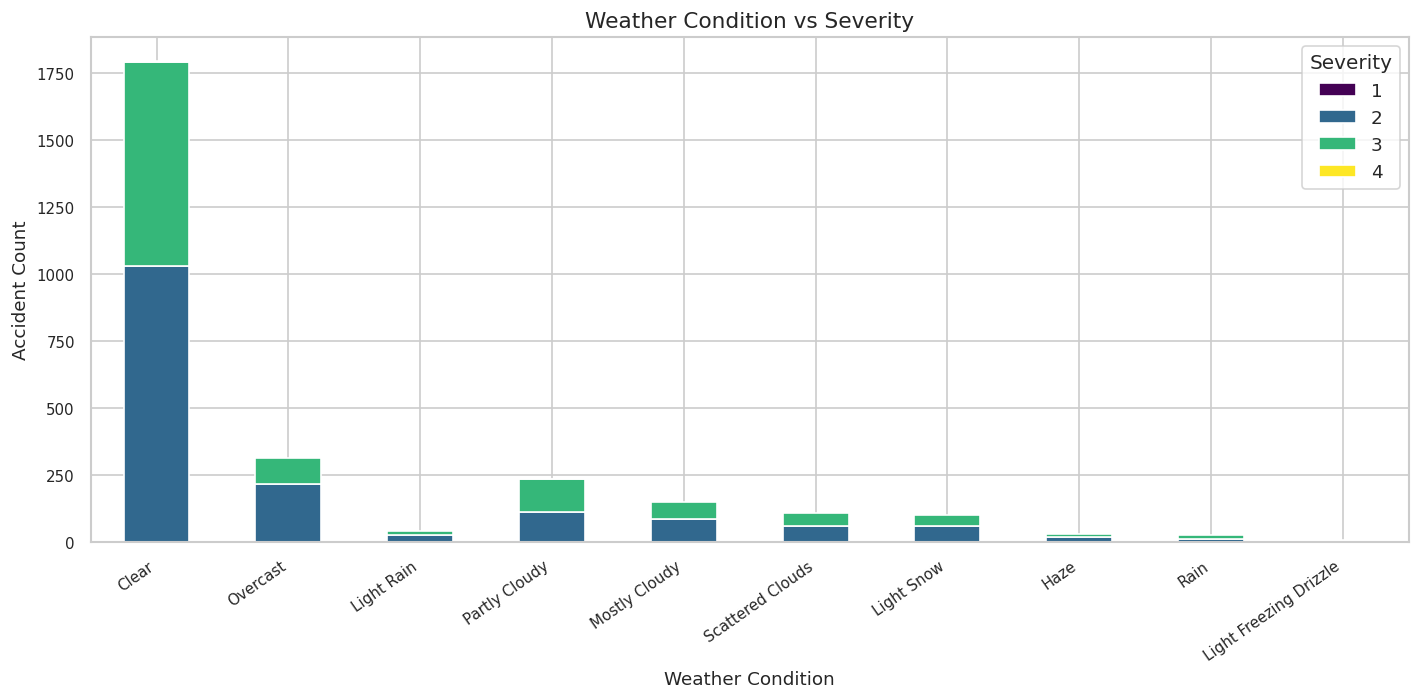


[STEP 12] Creating Visibility vs Severity Chart


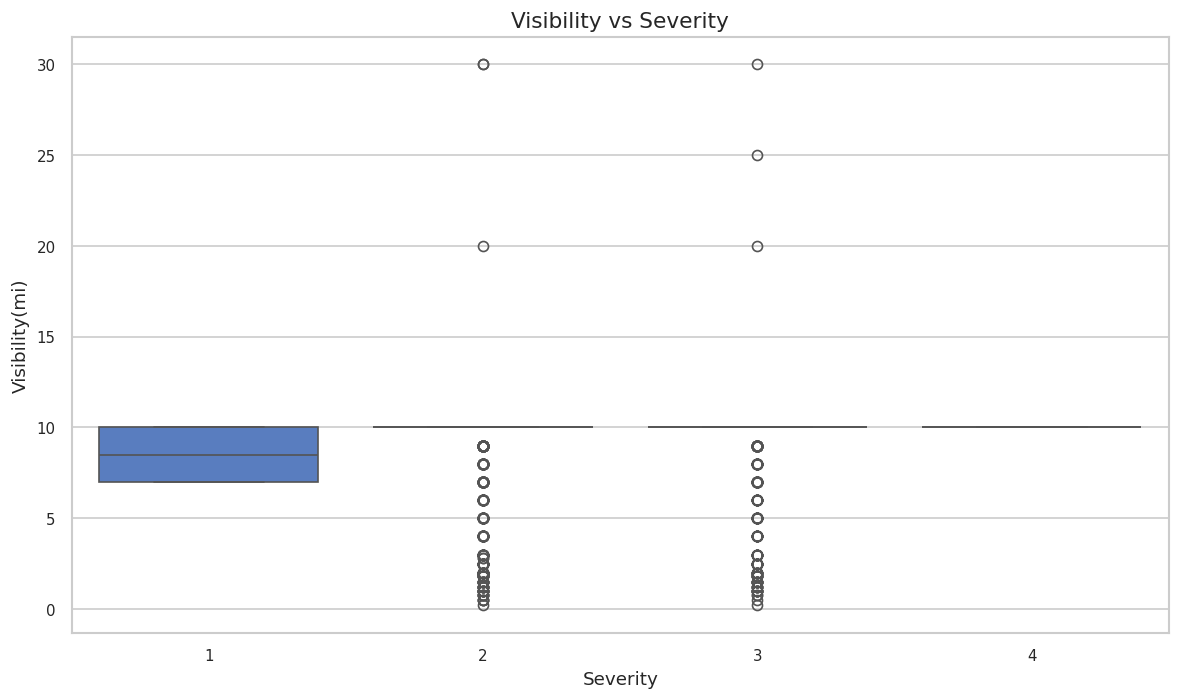


[STEP 13] Creating Folium Hotspot Map...
Hotspot map saved: outputs/Accident_Hotspots.html

[STEP 14] Creating Accident Location Map...
Accident_Locations.html saved successfully.

[STEP 15] Statistical Summary

Total accidents analysed : 2,857
Date range               : 2016-02-08 → 2016-07-12
States covered           : 3
Cities covered           : 313

Road Feature Presence (% of accidents):
  Junction             : 11.9%
  Traffic_Signal       : 13.1%
  Crossing             : 9.3%
  Stop                 : 4.2%

Peak accident hour       : 11:00
Day accidents            : 2,133  (74.7%)
Night accidents          : 723  (25.3%)
Weekend accidents        : 376  (13.2%)
Average visibility (mi)  : 9.2
Avg temperature (°F)     : 64.6

  KEY FINDINGS

1. Severity skew
   Severity 2 and 3 make up most accidents in the sample.

2. State concentration
   CA has the highest accident count with 2,128 records.

3. Weather pattern
   Clear is the most common weather condition with 1,795 records.
  

In [1]:
# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
import os

# ============================================================
# STEP 2 — CREATE OUTPUT FOLDER
# ============================================================

os.makedirs("outputs", exist_ok=True)

# ============================================================
# STEP 3 — GLOBAL SETTINGS
# ============================================================

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})

PALETTE = {
    "red": "#E74C3C",
    "orange": "#E67E22",
    "blue": "#2980B9",
    "green": "#27AE60",
    "purple": "#8E44AD",
    "teal": "#16A085",
    "grey": "#95A5A6"
}

SEV_COLORS = {
    1: "#2ECC71",
    2: "#F39C12",
    3: "#E67E22",
    4: "#C0392B"
}

# ============================================================
# STEP 4 — LOAD DATASET
# ============================================================

print("=" * 60)
print("  TRAFFIC ACCIDENT DATA ANALYSIS")
print("=" * 60)

print("\n[STEP 4] Loading dataset...")
df = pd.read_csv("accidents_sample.csv")

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

# ============================================================
# STEP 5 — DATA CLEANING
# ============================================================

print("\n[STEP 5] Data Cleaning")
print("-" * 50)

df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
invalid_dates = df["Start_Time"].isna().sum()
df.dropna(subset=["Start_Time"], inplace=True)
print(f"Removed {invalid_dates} rows with invalid datetime values.")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({"Missing": missing, "Pct%": missing_pct})
missing_report = missing_report[missing_report["Missing"] > 0].sort_values("Pct%", ascending=False)

if not missing_report.empty:
    print("\nMissing values summary:")
    print(missing_report.to_string())
else:
    print("\nNo missing values found.")

high_missing = missing_report[missing_report["Pct%"] > 80].index.tolist()
if high_missing:
    df.drop(columns=high_missing, inplace=True)
    print(f"\nDropped {len(high_missing)} columns with >80% missing values: {high_missing}")

print(f"Final shape after cleaning: {df.shape}")

# ============================================================
# STEP 6 — FEATURE ENGINEERING
# ============================================================

print("\n[STEP 6] Feature Engineering")
print("-" * 50)

df["Hour"] = df["Start_Time"].dt.hour
df["Day"] = df["Start_Time"].dt.day_name()
df["Month"] = df["Start_Time"].dt.month_name()
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)
df["TimeOfDay"] = pd.cut(
    df["Hour"],
    bins=[-1, 5, 11, 17, 20, 23],
    labels=["Night", "Morning", "Afternoon", "Evening", "Late Night"]
)

print("Created columns: Hour, Day, Month, DayOfWeek, IsWeekend, TimeOfDay")

# ============================================================
# STEP 7 — BASIC OVERVIEW
# ============================================================

print("\n[STEP 7] Dataset Overview")
print("-" * 50)

stats_cols = [c for c in ["Severity", "Temperature(F)", "Humidity(%)", "Visibility(mi)", "Distance(mi)", "Hour"] if c in df.columns]
print(df[stats_cols].describe().round(2).to_string())

print("\nSeverity Distribution:")
sev = df["Severity"].value_counts().sort_index()
for level, cnt in sev.items():
    label = {1: "Minor", 2: "Moderate", 3: "Serious", 4: "Critical"}.get(level, "")
    print(f"  Level {level} ({label}): {cnt:>6,} ({cnt/len(df)*100:.1f}%)")

print("\nTop 5 States:")
print(df["State"].value_counts().head(5).to_string())

print("\nTop Weather Conditions:")
print(df["Weather_Condition"].value_counts().head(5).to_string())

# ============================================================
# STEP 8 — FIGURE 1: OVERVIEW CHARTS
# ============================================================

print("\n[STEP 8] Creating Figure 1 — Overview Charts")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sev_labels = {1: "Minor (1)", 2: "Moderate (2)", 3: "Serious (3)", 4: "Critical (4)"}
sev_series = df["Severity"].value_counts().sort_index()

bars = axes[0, 0].bar(
    [sev_labels[i] for i in sev_series.index],
    sev_series.values,
    color=[SEV_COLORS[i] for i in sev_series.index],
    edgecolor="white",
    linewidth=1.2,
    width=0.55
)

for bar, val in zip(bars, sev_series.values):
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{val:,}\n({val/len(df)*100:.1f}%)",
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

axes[0, 0].set_title("Accident Severity Distribution", fontweight="bold")
axes[0, 0].set_ylabel("Number of Accidents")
axes[0, 0].set_ylim(0, sev_series.max() * 1.18)
axes[0, 0].spines[["top", "right"]].set_visible(False)

top_states = df["State"].value_counts().head(10)
colors_states = [PALETTE["orange"]] + [PALETTE["blue"]] * (len(top_states) - 1)

axes[0, 1].barh(
    top_states.index[::-1],
    top_states.values[::-1],
    color=colors_states[::-1],
    edgecolor="white",
    height=0.6
)

for i, val in enumerate(top_states.values[::-1]):
    axes[0, 1].text(val + 200, i, f"{val:,}", va="center", fontsize=8, fontweight="bold")

axes[0, 1].set_title("Top 10 States by Accident Count", fontweight="bold")
axes[0, 1].set_xlabel("Number of Accidents")
axes[0, 1].spines[["top", "right"]].set_visible(False)

top_weather = df["Weather_Condition"].value_counts().head(10)
axes[1, 0].barh(
    top_weather.index[::-1],
    top_weather.values[::-1],
    color=PALETTE["teal"],
    edgecolor="white",
    height=0.6
)

for i, val in enumerate(top_weather.values[::-1]):
    axes[1, 0].text(val + 100, i, f"{val:,}", va="center", fontsize=8, fontweight="bold")

axes[1, 0].set_title("Top 10 Weather Conditions", fontweight="bold")
axes[1, 0].set_xlabel("Number of Accidents")
axes[1, 0].spines[["top", "right"]].set_visible(False)

hour_counts = df.groupby("Hour").size()
axes[1, 1].bar(
    hour_counts.index,
    hour_counts.values,
    color=[PALETTE["red"] if h in [7, 8, 9, 17, 18] else PALETTE["blue"] for h in hour_counts.index],
    edgecolor="white",
    alpha=0.85
)
axes[1, 1].plot(hour_counts.index, hour_counts.values, color="black", linewidth=1.5, marker="o", markersize=3)
axes[1, 1].set_title("Accidents by Hour of Day\n(Red = Rush Hours)", fontweight="bold")
axes[1, 1].set_xlabel("Hour (0–23)")
axes[1, 1].set_ylabel("Number of Accidents")
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Traffic Accident Analysis — Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/fig1_overview.png", bbox_inches="tight")
plt.show()

print("\nFIGURE 1 — OBSERVATIONS:")
top_state = df["State"].value_counts().idxmax()
top_state_count = df["State"].value_counts().max()
top_weather = df["Weather_Condition"].value_counts().idxmax()
top_weather_count = df["Weather_Condition"].value_counts().max()
peak_hour = df["Hour"].value_counts().idxmax()

print(f"{top_state} dominates with {top_state_count:,} accidents.")
print(f"{top_weather} is the most frequent weather condition with {top_weather_count:,} accidents.")
print(f"Peak accident hour is around {peak_hour}:00.")

# ============================================================
# STEP 9 — FIGURE 2: TIME AND ROAD FEATURES
# ============================================================

print("\n[STEP 9] Creating Figure 2 — Time and Road Features")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = df["Day"].value_counts().reindex(day_order)
weekend_colors = [PALETTE["red"] if d in ["Saturday", "Sunday"] else PALETTE["blue"] for d in day_order]

axes[0, 0].bar(day_order, day_counts.values, color=weekend_colors, edgecolor="white", width=0.6)
axes[0, 0].set_title("Accidents by Day of Week\n(Red = Weekends)", fontweight="bold")
axes[0, 0].set_xlabel("Day")
axes[0, 0].set_ylabel("Accidents")
axes[0, 0].tick_params(axis="x", rotation=35)

for i, v in enumerate(day_counts.values):
    axes[0, 0].text(i, v + 100, f"{v:,}", ha="center", fontsize=7.5, fontweight="bold")

axes[0, 0].spines[["top", "right"]].set_visible(False)

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
month_counts = df["Month"].value_counts().reindex(month_order)

axes[0, 1].bar(range(12), month_counts.values, color=PALETTE["purple"], edgecolor="white", alpha=0.85)
axes[0, 1].set_title("Accidents by Month", fontweight="bold")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Accidents")
axes[0, 1].set_xticks(range(12))
axes[0, 1].set_xticklabels([m[:3] for m in month_order], rotation=0)
axes[0, 1].spines[["top", "right"]].set_visible(False)

day_night = df["Sunrise_Sunset"].value_counts()
wedge_props = dict(width=0.5, edgecolor="white", linewidth=2.5)

pie_ax = axes[1, 0]
pie_ax.pie(
    day_night.values,
    labels=day_night.index,
    colors=[PALETTE["orange"], PALETTE["blue"]],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=wedge_props,
    textprops={"fontsize": 11, "fontweight": "bold"}
)
pie_ax.set_title("Day vs Night Accidents", fontweight="bold")

road_features = ["Junction", "Traffic_Signal", "Crossing", "Stop", "Amenity", "Bump"]
feature_pcts = {f: df[f].mean() * 100 for f in road_features if f in df.columns}
feat_colors = [PALETTE["red"] if v > 10 else PALETTE["blue"] for v in feature_pcts.values()]

feat_bars = axes[1, 1].bar(
    feature_pcts.keys(),
    feature_pcts.values(),
    color=feat_colors,
    edgecolor="white",
    width=0.55
)

axes[1, 1].set_title("Road Feature Presence at Accident Sites (%)", fontweight="bold")
axes[1, 1].set_ylabel("Accidents at Feature (%)")
axes[1, 1].tick_params(axis="x", rotation=25)

for bar, val in zip(feat_bars, feature_pcts.values()):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

axes[1, 1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Traffic Accident Analysis — Time & Road Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/fig2_time_road.png", bbox_inches="tight")
plt.show()

# ============================================================
# STEP 10 — FIGURE 3: DEEP DIVE
# ============================================================

print("\n[STEP 10] Creating Figure 3 — Deep Dive")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

top_cities = df["City"].value_counts().head(10)
axes[0, 0].barh(top_cities.index[::-1], top_cities.values[::-1],
                color=PALETTE["orange"], edgecolor="white", height=0.6)

for i, val in enumerate(top_cities.values[::-1]):
    axes[0, 0].text(val + 50, i, f"{val:,}", va="center", fontsize=8, fontweight="bold")

axes[0, 0].set_title("Top 10 Cities by Accident Count", fontweight="bold")
axes[0, 0].set_xlabel("Number of Accidents")
axes[0, 0].spines[["top", "right"]].set_visible(False)

tod_order = ["Night", "Morning", "Afternoon", "Evening", "Late Night"]
tod_sev = df.groupby(["TimeOfDay", "Severity"]).size().unstack(fill_value=0).reindex(tod_order)

x = np.arange(len(tod_order))
width = 0.2

for i, sev_level in enumerate(sorted(tod_sev.columns)):
    if sev_level in SEV_COLORS:
        axes[0, 1].bar(
            x + i * width,
            tod_sev[sev_level],
            width,
            label=f"Severity {sev_level}",
            color=SEV_COLORS[sev_level],
            edgecolor="white"
        )

axes[0, 1].set_title("Accident Severity by Time of Day", fontweight="bold")
axes[0, 1].set_xticks(x + width * 1.5)
axes[0, 1].set_xticklabels(tod_order, rotation=15)
axes[0, 1].set_ylabel("Accidents")
axes[0, 1].legend(fontsize=8, title="Severity")
axes[0, 1].spines[["top", "right"]].set_visible(False)

temp_df = df[df["Temperature(F)"].notna()]
for sev_level, color in SEV_COLORS.items():
    data = temp_df[temp_df["Severity"] == sev_level]["Temperature(F)"]
    if len(data) > 10:
        axes[1, 0].hist(
            data,
            bins=40,
            alpha=0.55,
            color=color,
            label=f"Severity {sev_level}",
            edgecolor="white",
            linewidth=0.3
        )

axes[1, 0].set_title("Temperature Distribution by Severity", fontweight="bold")
axes[1, 0].set_xlabel("Temperature (°F)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend(fontsize=8, title="Severity")
axes[1, 0].spines[["top", "right"]].set_visible(False)

heatmap_cols = [c for c in ["Severity", "Temperature(F)", "Humidity(%)", "Visibility(mi)", "Pressure(in)", "Distance(mi)", "Hour"] if c in df.columns]
corr_df = df[heatmap_cols].corr()

sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8},
    ax=axes[1, 1]
)

axes[1, 1].set_title("Correlation Heatmap — Key Features", fontweight="bold")
plt.setp(axes[1, 1].get_xticklabels(), rotation=30, ha="right")
plt.setp(axes[1, 1].get_yticklabels(), rotation=0)

plt.suptitle("Traffic Accident Analysis — Deep Dive", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/fig3_deepdive.png", bbox_inches="tight")
plt.show()

# ============================================================
# STEP 11 — WEATHER VS SEVERITY
# ============================================================

print("\n[STEP 11] Creating Weather vs Severity Chart")

if "Weather_Condition" in df.columns and "Severity" in df.columns:
    weather_severity = pd.crosstab(df["Weather_Condition"], df["Severity"])
    weather_severity = weather_severity.sort_values(by=weather_severity.columns.tolist(), ascending=False).head(10)

    ax = weather_severity.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
    plt.title("Weather Condition vs Severity")
    plt.xlabel("Weather Condition")
    plt.ylabel("Accident Count")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig("outputs/weather_vs_severity.png", bbox_inches="tight")
    plt.show()

# ============================================================
# STEP 12 — VISIBILITY VS SEVERITY
# ============================================================

print("\n[STEP 12] Creating Visibility vs Severity Chart")

if "Visibility(mi)" in df.columns and "Severity" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Severity", y="Visibility(mi)", data=df)
    plt.title("Visibility vs Severity")
    plt.tight_layout()
    plt.savefig("outputs/visibility_vs_severity.png", bbox_inches="tight")
    plt.show()

# ============================================================
# STEP 13 — FOLIUM HOTSPOT MAP
# ============================================================

print("\n[STEP 13] Creating Folium Hotspot Map...")

coord_df = df[["Start_Lat", "Start_Lng"]].dropna()
map_df = coord_df.sample(min(5000, len(coord_df)), random_state=42)

m = folium.Map(
    location=[map_df["Start_Lat"].mean(), map_df["Start_Lng"].mean()],
    zoom_start=5,
    tiles="CartoDB positron"
)

HeatMap(
    map_df.values.tolist(),
    radius=10,
    blur=12,
    min_opacity=0.4,
    max_zoom=10
).add_to(m)

top_city_row = df.groupby("City").agg(
    count=("Severity", "count"),
    lat=("Start_Lat", "mean"),
    lng=("Start_Lng", "mean")
).sort_values("count", ascending=False).iloc[0]

folium.Marker(
    location=[top_city_row["lat"], top_city_row["lng"]],
    popup=f"Highest Accident City: {top_city_row.name} ({int(top_city_row['count']):,} accidents)",
    icon=folium.Icon(color="red", icon="warning-sign", prefix="glyphicon")
).add_to(m)

title_html = """
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
     background: white; padding: 8px 18px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 14px; font-weight: bold;
     z-index: 9999; box-shadow: 2px 2px 6px rgba(0,0,0,0.2);">
     US Traffic Accident Hotspots
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))
m.save("outputs/Accident_Hotspots.html")
print("Hotspot map saved: outputs/Accident_Hotspots.html")

# ============================================================
# STEP 14 — OPTIONAL ACCIDENT LOCATION MAP
# ============================================================

print("\n[STEP 14] Creating Accident Location Map...")

m2 = folium.Map(
    location=[39.5, -98.35],
    zoom_start=4,
    tiles="CartoDB positron"
)

sample_points = coord_df.sample(min(1000, len(coord_df)), random_state=42)

for _, row in sample_points.iterrows():
    folium.CircleMarker(
        location=[row["Start_Lat"], row["Start_Lng"]],
        radius=2,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.6
    ).add_to(m2)

m2.save("outputs/Accident_Locations.html")
print("Accident_Locations.html saved successfully.")

# ============================================================
# STEP 15 — STATISTICAL SUMMARY
# ============================================================

print("\n[STEP 15] Statistical Summary")
print("=" * 60)

print(f"\nTotal accidents analysed : {len(df):,}")
print(f"Date range               : {df['Start_Time'].min().date()} → {df['Start_Time'].max().date()}")
print(f"States covered           : {df['State'].nunique()}")
print(f"Cities covered           : {df['City'].nunique():,}")

print("\nRoad Feature Presence (% of accidents):")
for feat in ["Junction", "Traffic_Signal", "Crossing", "Stop"]:
    if feat in df.columns:
        pct = df[feat].mean() * 100
        print(f"  {feat:<20} : {pct:.1f}%")

print(f"\nPeak accident hour       : {df['Hour'].value_counts().idxmax()}:00")
print(f"Day accidents            : {(df['Sunrise_Sunset']=='Day').sum():,}  ({(df['Sunrise_Sunset']=='Day').mean()*100:.1f}%)")
print(f"Night accidents          : {(df['Sunrise_Sunset']=='Night').sum():,}  ({(df['Sunrise_Sunset']=='Night').mean()*100:.1f}%)")
print(f"Weekend accidents        : {df['IsWeekend'].sum():,}  ({df['IsWeekend'].mean()*100:.1f}%)")

if "Visibility(mi)" in df.columns:
    print(f"Average visibility (mi)  : {df['Visibility(mi)'].mean():.1f}")
if "Temperature(F)" in df.columns:
    print(f"Avg temperature (°F)     : {df['Temperature(F)'].mean():.1f}")

# ============================================================
# STEP 16 — KEY FINDINGS
# ============================================================

print("\n" + "=" * 60)
print("  KEY FINDINGS")
print("=" * 60)

top_state = df["State"].value_counts().idxmax()
top_state_count = df["State"].value_counts().max()
top_weather = df["Weather_Condition"].value_counts().idxmax()
top_weather_count = df["Weather_Condition"].value_counts().max()
top_city = df["City"].value_counts().idxmax()
top_city_count = df["City"].value_counts().max()

print(f"""
1. Severity skew
   Severity 2 and 3 make up most accidents in the sample.

2. State concentration
   {top_state} has the highest accident count with {top_state_count:,} records.

3. Weather pattern
   {top_weather} is the most common weather condition with {top_weather_count:,} records.
   Raw counts should be interpreted with weather frequency in mind.

4. Visibility matters
   Lower visibility appears more associated with higher severity, which is why the boxplot is useful.

5. Hotspots
   {top_city} is the highest-concentration city in this dataset with {top_city_count:,} accidents.

6. Road features
   Junctions, crossings, and traffic signals appear repeatedly as accident-prone locations.
""")

# ============================================================
# STEP 17 — FINAL CONCLUSION
# ============================================================

print("=" * 60)
print("  PROJECT CONCLUSION")
print("=" * 60)

print(f"""
This analysis of {len(df):,} traffic accident records identified patterns in
timing, geography, weather, visibility, and road infrastructure.

Updated outputs include:
- outputs/fig1_overview.png
- outputs/fig2_time_road.png
- outputs/fig3_deepdive.png
- outputs/weather_vs_severity.png
- outputs/visibility_vs_severity.png
- outputs/Accident_Hotspots.html
- outputs/Accident_Locations.html
""")

print("=" * 60)
print("PROJECT ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 60)

In [1]:
import os

print("Current directory:", os.getcwd())
print("\nOutputs folder contents:")

for file in os.listdir("outputs"):
    print(file)

Current directory: /content

Outputs folder contents:
fig3_deepdive.png
Accident_Locations.html
Accident_Hotspots.html
fig2_time_road.png
weather_vs_severity.png
visibility_vs_severity.png
fig1_overview.png
